# Sleep-stage classification — Boosting models

Companion to `inception.ipynb` (which developed a **RandomForest**). Same data, same
leak-free validation, same competition metric (**macro-F1**, 4 balanced classes), but the
modelling engine here is **gradient boosting**:

- `HistGradientBoosting` (sklearn — always available, handles NaN natively)
- `XGBoost`
- `LightGBM`
- `CatBoost`
- `GradientBoosting` (sklearn, classic) as a slow reference

Plan: preprocess → boosting baseline ladder → feature engineering → tune the best booster →
per-class threshold optimization for macro-F1 → stability check → soft-voting blend → submission.

## 0. Dependencies

`xgboost`, `lightgbm`, `catboost` are pip-installable. Run this once if they're missing;
the notebook still works on whichever subset is importable (it filters to what's available).

In [1]:
# Run if needed (uncomment):
# %pip install -q xgboost lightgbm catboost

import importlib
_avail = {}
for _lib in ("xgboost", "lightgbm", "catboost"):
    try:
        importlib.import_module(_lib)
        _avail[_lib] = True
    except ImportError:
        _avail[_lib] = False
print("available boosting libs:", _avail)
print("(HistGradientBoosting + GradientBoosting come from sklearn, always available)")

available boosting libs: {'xgboost': True, 'lightgbm': True, 'catboost': True}
(HistGradientBoosting + GradientBoosting come from sklearn, always available)


## 1. Load data

Identical setup to `inception.ipynb`: 21 float features, integer target `sleep_stage`
(0–3), `test.csv` used only for the final submission.

In [2]:
import numpy as np
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

target = "sleep_stage"
num_features = [c for c in train.columns if c not in ("id", target)]
classes = sorted(train[target].unique())

print("train:", train.shape, "| test:", test.shape)
print("features:", len(num_features), "| classes:", classes)
print("class balance:\n", train[target].value_counts(normalize=True).sort_index().round(3))

train: (9000, 23) | test: (5000, 22)
features: 21 | classes: [0, 1, 2, 3]
class balance:
 sleep_stage
0    0.222
1    0.271
2    0.249
3    0.258
Name: proportion, dtype: float64


## 2. Preprocessing (same recipe as inception)

EDA in `inception.ipynb` established: only `eog_burst_index` has missing values
(~50% train / ~28% test); classes are balanced; features are pre-standardized; train≈test
(no drift, adversarial AUC≈0.5); ids disjoint and no temporal autocorrelation → a shuffled
`StratifiedKFold` is the correct CV.

Two design choices that matter for boosting:

- **Native NaN handling.** HistGB, XGBoost, LightGBM and CatBoost all learn a default
  direction for missing values, so we can feed NaNs *directly* and let the tree decide —
  often better than median imputation. We keep an imputing pipeline only for the sklearn
  `GradientBoosting` reference, which cannot take NaNs.
- **Missing-flag feature.** §10 of inception found the missingness weakly informative; the
  feature search below re-tests whether boosters benefit from an explicit
  `eog_burst_index_missing` flag.

In [3]:
from sklearn.model_selection import StratifiedKFold

# Raw matrices: keep NaNs so native-NaN boosters can exploit them.
Xr = train[num_features].copy()
yr = train[target].values

# Leak-free CV: shuffled stratified 5-fold (justified by inception §13).
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("NaNs kept in Xr (only eog_burst_index):", int(Xr.isna().sum().sum()))
print("Xr:", Xr.shape, "| y classes:", sorted(np.unique(yr)))

NaNs kept in Xr (only eog_burst_index): 4501
Xr: (9000, 21) | y classes: [0, 1, 2, 3]


## 3. Boosting model zoo

A factory that returns a fresh dict of estimators, filtered to the libraries actually
installed. Each is configured with sensible, *comparable* defaults (similar tree counts /
learning rates) so the ladder is a fair fight rather than a tuning contest. `random_state`
fixed everywhere for reproducibility; all run single-process here so the CV loop can
parallelize across folds.

In [4]:
from sklearn.ensemble import HistGradientBoostingClassifier, GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline

RNG = 42

def make_boosters(include_slow=False):
    """Fresh estimators each call (so CV folds don't share fitted state)."""
    m = {}

    # sklearn HistGradientBoosting — fast, histogram-based, native NaN support.
    m["HistGB"] = HistGradientBoostingClassifier(
        max_iter=400, learning_rate=0.05, max_depth=None, max_leaf_nodes=31,
        l2_regularization=1.0, early_stopping=False, random_state=RNG,
    )

    if _avail.get("xgboost"):
        from xgboost import XGBClassifier
        m["XGBoost"] = XGBClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            objective="multi:softprob", num_class=len(classes),
            tree_method="hist", eval_metric="mlogloss",
            random_state=RNG, n_jobs=1,
        )

    if _avail.get("lightgbm"):
        from lightgbm import LGBMClassifier
        m["LightGBM"] = LGBMClassifier(
            n_estimators=400, learning_rate=0.05, num_leaves=31,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            objective="multiclass", num_class=len(classes),
            random_state=RNG, n_jobs=1, verbose=-1,
        )

    if _avail.get("catboost"):
        from catboost import CatBoostClassifier
        m["CatBoost"] = CatBoostClassifier(
            iterations=400, learning_rate=0.05, depth=6, l2_leaf_reg=3.0,
            loss_function="MultiClass", random_seed=RNG, verbose=0,
        )

    # Classic sklearn GradientBoosting — slow; needs imputation (no native NaN).
    if include_slow:
        m["GradientBoosting"] = make_pipeline(
            SimpleImputer(strategy="median"),
            GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                       max_depth=3, random_state=RNG),
        )
    return m

print("models this run:", list(make_boosters(include_slow=True).keys()))

models this run: ['HistGB', 'XGBoost', 'LightGBM', 'CatBoost', 'GradientBoosting']


## 4. Baseline ladder (macro-F1, out-of-fold)

Each model is scored with **out-of-fold** predictions on the shared `StratifiedKFold(5)`.
Boosters receive raw features with NaNs intact; only `GradientBoosting` imputes inside its
pipeline. We report macro-F1 (primary) + accuracy and time each model so we know the
speed/quality trade-off before committing.

In [5]:
import time
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score, accuracy_score, classification_report

oof_pred = {}
rows = []
for name, mdl in make_boosters(include_slow=True).items():
    t0 = time.perf_counter()
    pred = cross_val_predict(mdl, Xr, yr, cv=cv, n_jobs=-1)
    dt = time.perf_counter() - t0
    oof_pred[name] = pred
    rows.append({"model": name,
                 "macro_F1": f1_score(yr, pred, average="macro"),
                 "accuracy": accuracy_score(yr, pred),
                 "fit_sec": round(dt, 1)})

board = pd.DataFrame(rows).sort_values("macro_F1", ascending=False).reset_index(drop=True)
print(board.to_string(index=False))

BEST_NAME = board.iloc[0]["model"]
print(f"\nBest baseline booster: {BEST_NAME}")
print(f"\nclassification_report — {BEST_NAME} (out-of-fold):\n")
print(classification_report(yr, oof_pred[BEST_NAME], digits=3))

           model  macro_F1  accuracy  fit_sec
         XGBoost  0.822343  0.822222     40.6
        LightGBM  0.821639  0.821444     17.0
        CatBoost  0.818384  0.818778     32.8
          HistGB  0.817337  0.817222     48.3
GradientBoosting  0.799333  0.799222    100.9

Best baseline booster: XGBoost

classification_report — XGBoost (out-of-fold):

              precision    recall  f1-score   support

           0      0.856     0.841     0.848      2001
           1      0.838     0.848     0.843      2442
           2      0.773     0.768     0.771      2237
           3      0.824     0.832     0.828      2320

    accuracy                          0.822      9000
   macro avg      0.823     0.822     0.822      9000
weighted avg      0.822     0.822     0.822      9000



## 5. Confusion matrix of the best booster

Row-normalized confusion (each row = true class → where it lands) to see which stages get
confused. inception found **class 2** weakest and leaking into its ordinal neighbours;
we check whether boosting changes that pattern.

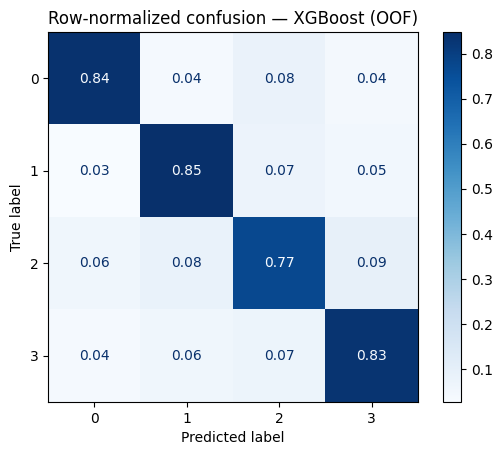

Weakest class by recall: 2  (recall=0.768)
It gets predicted as: {0: 5.7, 1: 8.3, 2: 76.8, 3: 9.3}


In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(yr, oof_pred[BEST_NAME], normalize="true")
ConfusionMatrixDisplay(cm, display_labels=classes).plot(cmap="Blues", values_format=".2f")
plt.title(f"Row-normalized confusion — {BEST_NAME} (OOF)")
plt.show()

worst = int(np.argmin(np.diag(cm)))
print(f"Weakest class by recall: {worst}  (recall={cm[worst, worst]:.3f})")
print("It gets predicted as:",
      dict(zip(classes, (cm[worst] * 100).round(1).tolist())))

## 6. Feature engineering search

Same `build()` contract as inception (identical logic for train/test, reused verbatim at
submission). We test, with a fixed fast `HistGB`:

- **base** — all 21 raw features.
- **drop `body_movement_index`** — MI≈0 in inception §8.
- **+ missing flag** — explicit `eog_burst_index_missing`.
- **+ interactions** — pairwise products of the top-5 MI features (boosters split
  axis-aligned, so explicit interactions *can* help even though they handle non-linearity).

Keep the recipe with the best CV macro-F1.

In [7]:
import itertools
from sklearn.model_selection import cross_val_score
from sklearn.base import clone

TOP = ["heart_rate_variability", "eog_burst_index", "eog_movement_density",
       "eeg_alpha_power", "respiration_rate"]

def build(df, drop_bmi=True, interactions=False, flag=False):
    """Build a feature matrix; identical logic for train and test (NaNs preserved)."""
    cols = [c for c in num_features if not (drop_bmi and c == "body_movement_index")]
    out = df[cols].copy()
    if interactions:
        for a, b in itertools.combinations(TOP, 2):
            out[f"{a}*{b}"] = df[a] * df[b]
    if flag:
        out["eog_burst_index_missing"] = df["eog_burst_index"].isna().astype(int)
    return out

# Light, fast probe model for the search.
probe = HistGradientBoostingClassifier(max_iter=300, learning_rate=0.06,
                                       max_leaf_nodes=31, random_state=RNG)

configs = {
    "base (all 21)":                  dict(drop_bmi=False),
    "drop bmi":                       dict(),
    "drop bmi + flag":                dict(flag=True),
    "drop bmi + interactions":        dict(interactions=True),
    "drop bmi + interactions + flag": dict(interactions=True, flag=True),
}
fe = pd.Series({
    name: cross_val_score(clone(probe), build(train, **kw), yr,
                          cv=cv, scoring="f1_macro", n_jobs=-1).mean()
    for name, kw in configs.items()
}).sort_values(ascending=False)

print("CV macro-F1 by feature set (HistGB probe):")
print(fe.round(4).to_string())

BEST_KW = configs[fe.index[0]]
print(f"\nChosen feature set: '{fe.index[0]}'  ->  {BEST_KW}")
X_fe = build(train, **BEST_KW)
print("n features:", X_fe.shape[1])

CV macro-F1 by feature set (HistGB probe):
base (all 21)                     0.8190
drop bmi                          0.8171
drop bmi + flag                   0.8171
drop bmi + interactions           0.8162
drop bmi + interactions + flag    0.8162

Chosen feature set: 'base (all 21)'  ->  {'drop_bmi': False}
n features: 21


## 7. Hyperparameter tuning — best booster

`RandomizedSearchCV` (25 iters) over the winning booster's key knobs, optimizing macro-F1
on a lighter `StratifiedKFold(3)` for speed. The search space is chosen per library
(learning rate / depth / regularization / sampling). Best estimator → `tuned`.

If the best booster is HistGB we tune sklearn params directly; otherwise we tune the
library estimator. Either way the result is a single fitted classifier on the engineered
features.

In [8]:
from sklearn.model_selection import RandomizedSearchCV

search_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

def tuning_spec(name):
    """Return (estimator, param_distributions) for the chosen booster."""
    if name == "HistGB":
        est = HistGradientBoostingClassifier(random_state=RNG)
        grid = {
            "learning_rate":   [0.02, 0.03, 0.05, 0.08],
            "max_iter":        [300, 500, 800],
            "max_leaf_nodes":  [15, 31, 63],
            "min_samples_leaf":[10, 20, 40],
            "l2_regularization":[0.0, 0.5, 1.0, 2.0],
            "max_features":    [0.6, 0.8, 1.0],
        }
        return est, grid
    if name == "XGBoost":
        from xgboost import XGBClassifier
        est = XGBClassifier(objective="multi:softprob", num_class=len(classes),
                            tree_method="hist", eval_metric="mlogloss",
                            random_state=RNG, n_jobs=1)
        grid = {
            "n_estimators":   [300, 500, 800],
            "learning_rate":  [0.02, 0.03, 0.05, 0.08],
            "max_depth":      [4, 6, 8],
            "subsample":      [0.7, 0.8, 1.0],
            "colsample_bytree":[0.7, 0.8, 1.0],
            "reg_lambda":     [0.5, 1.0, 2.0, 5.0],
            "min_child_weight":[1, 3, 5],
        }
        return est, grid
    if name == "LightGBM":
        from lightgbm import LGBMClassifier
        est = LGBMClassifier(objective="multiclass", num_class=len(classes),
                             random_state=RNG, n_jobs=1, verbose=-1)
        grid = {
            "n_estimators":   [300, 500, 800],
            "learning_rate":  [0.02, 0.03, 0.05, 0.08],
            "num_leaves":     [15, 31, 63],
            "subsample":      [0.7, 0.8, 1.0],
            "colsample_bytree":[0.7, 0.8, 1.0],
            "reg_lambda":     [0.5, 1.0, 2.0, 5.0],
            "min_child_samples":[10, 20, 40],
        }
        return est, grid
    if name == "CatBoost":
        from catboost import CatBoostClassifier
        est = CatBoostClassifier(loss_function="MultiClass", random_seed=RNG, verbose=0)
        grid = {
            "iterations":   [300, 500, 800],
            "learning_rate":[0.02, 0.03, 0.05, 0.08],
            "depth":        [4, 6, 8],
            "l2_leaf_reg":  [1.0, 3.0, 5.0, 7.0],
        }
        return est, grid
    raise ValueError(name)

est, grid = tuning_spec(BEST_NAME)
search = RandomizedSearchCV(est, grid, n_iter=25, scoring="f1_macro",
                            cv=search_cv, random_state=RNG, n_jobs=-1, verbose=1, refit=True)
search.fit(X_fe, yr)

tuned = search.best_estimator_
print(f"\nBest search macro-F1 (3-fold): {search.best_score_:.4f}")
print("Best params:")
for k, v in search.best_params_.items():
    print(f"  {k:20s} = {v}")

Fitting 3 folds for each of 25 candidates, totalling 75 fits

Best search macro-F1 (3-fold): 0.8192
Best params:
  subsample            = 0.7
  reg_lambda           = 5.0
  n_estimators         = 300
  min_child_weight     = 1
  max_depth            = 8
  learning_rate        = 0.05
  colsample_bytree     = 0.8


## 8. Tuned model — out-of-fold evaluation

Score the tuned booster honestly on the unbiased 5-fold CV, and cache its OOF
probabilities — they feed both the threshold optimization (§9) and the blend (§11).

In [9]:
oof_proba_tuned = cross_val_predict(tuned, X_fe, yr, cv=cv,
                                    method="predict_proba", n_jobs=-1)
labels = np.array(sorted(np.unique(yr)))
oof_argmax = labels[oof_proba_tuned.argmax(1)]

print(f"Tuned {BEST_NAME} — OOF macro-F1 (argmax) = "
      f"{f1_score(yr, oof_argmax, average='macro'):.4f}")
print("\nOOF classification report:\n")
print(classification_report(yr, oof_argmax, digits=3))

Tuned XGBoost — OOF macro-F1 (argmax) = 0.8207

OOF classification report:

              precision    recall  f1-score   support

           0      0.851     0.838     0.844      2001
           1      0.839     0.849     0.844      2442
           2      0.773     0.768     0.771      2237
           3      0.821     0.826     0.824      2320

    accuracy                          0.821      9000
   macro avg      0.821     0.820     0.821      9000
weighted avg      0.821     0.821     0.821      9000



## 9. Per-class threshold optimization (macro-F1)

`argmax(proba)` maximizes accuracy, not macro-F1. We learn a per-class probability
**multiplier** via coordinate ascent on the **out-of-fold** probabilities (leak-free), then
predict with `argmax(proba * class_mult)`. The learned `class_mult` is reused for the test
predictions in §12. (Same technique as inception §19.)

In [10]:
def fit_class_mult(proba, y, labels, grid=None):
    if grid is None:
        grid = np.round(np.linspace(0.5, 2.0, 31), 3)
    mult = np.ones(proba.shape[1])
    improved = True
    while improved:
        improved = False
        for k in range(len(mult)):
            best_m = mult[k]
            best_s = f1_score(y, labels[(proba * mult).argmax(1)], average="macro")
            for m in grid:
                cand = mult.copy(); cand[k] = m
                s = f1_score(y, labels[(proba * cand).argmax(1)], average="macro")
                if s > best_s:
                    best_s, best_m = s, m
            if best_m != mult[k]:
                mult[k] = best_m; improved = True
    return mult

class_mult = fit_class_mult(oof_proba_tuned, yr, labels)
opt_pred = labels[(oof_proba_tuned * class_mult).argmax(1)]

f1_argmax = f1_score(yr, oof_argmax, average="macro")
f1_opt = f1_score(yr, opt_pred, average="macro")
print(f"OOF macro-F1  argmax    = {f1_argmax:.4f}")
print(f"OOF macro-F1  optimized = {f1_opt:.4f}   (+{f1_opt - f1_argmax:.4f})")
print("class multipliers:", dict(zip(labels.tolist(), class_mult.round(3).tolist())))
print("\nOptimized-threshold OOF report:\n")
print(classification_report(yr, opt_pred, digits=3))

OOF macro-F1  argmax    = 0.8207
OOF macro-F1  optimized = 0.8222   (+0.0015)
class multipliers: {0: 1.05, 1: 1.15, 2: 1.05, 3: 0.9}

Optimized-threshold OOF report:

              precision    recall  f1-score   support

           0      0.852     0.840     0.846      2001
           1      0.832     0.860     0.846      2442
           2      0.771     0.773     0.772      2237
           3      0.837     0.814     0.825      2320

    accuracy                          0.822      9000
   macro avg      0.823     0.822     0.822      9000
weighted avg      0.822     0.822     0.822      9000



## 10. Stability check (seed variation)

Boosting is stochastic (row/column subsampling). Re-evaluate the tuned model's OOF
macro-F1 across seeds to confirm the score isn't a lucky draw. Reported mean ± std.

In [11]:
def set_seed(est, s):
    e = clone(est)
    for p in ("random_state", "random_seed", "seed"):
        if p in e.get_params():
            e.set_params(**{p: s}); break
    return e

seeds = [0, 1, 2]
seed_scores = []
for s in seeds:
    pred = cross_val_predict(set_seed(tuned, s), X_fe, yr, cv=cv, n_jobs=-1)
    seed_scores.append(f1_score(yr, pred, average="macro"))
seed_scores = np.array(seed_scores)
print("per-seed OOF macro-F1:", dict(zip(seeds, seed_scores.round(4).tolist())))
print(f"mean = {seed_scores.mean():.4f}  std = {seed_scores.std():.4f}")

per-seed OOF macro-F1: {0: 0.8196, 1: 0.8215, 2: 0.8215}
mean = 0.8209  std = 0.0009


## 11. Soft-voting blend of boosters

Boosters of different families make partly-independent errors, so averaging their
probabilities often beats any single one. We average **out-of-fold** probabilities of all
available boosters (tuned best + the rest at their baseline configs), optimize thresholds on
the blended OOF, and keep the blend only if it beats the tuned single model. The exact
`weights`/members chosen here are reused at submission.

In [12]:
# Collect OOF probabilities for every available booster on the engineered features.
blend_members = {}
blend_members[BEST_NAME] = tuned  # tuned best
for name, mdl in make_boosters(include_slow=False).items():
    if name != BEST_NAME:
        blend_members[name] = mdl

oof_probas = {}
for name, mdl in blend_members.items():
    oof_probas[name] = cross_val_predict(clone(mdl), X_fe, yr, cv=cv,
                                         method="predict_proba", n_jobs=-1)

# Simple unweighted average blend.
blend_oof = np.mean([oof_probas[n] for n in blend_members], axis=0)
blend_mult = fit_class_mult(blend_oof, yr, labels)
blend_pred = labels[(blend_oof * blend_mult).argmax(1)]
f1_blend = f1_score(yr, blend_pred, average="macro")

print("blend members:", list(blend_members))
for n in blend_members:
    print(f"  {n:16s} OOF macro-F1 = "
          f"{f1_score(yr, labels[oof_probas[n].argmax(1)], average='macro'):.4f}")
print(f"\nTuned single  (opt thr) = {f1_opt:.4f}")
print(f"Blend         (opt thr) = {f1_blend:.4f}")

USE_BLEND = f1_blend > f1_opt
print("\n-> using", "BLEND" if USE_BLEND else "TUNED SINGLE", "for submission")

blend members: ['XGBoost', 'HistGB', 'LightGBM', 'CatBoost']
  XGBoost          OOF macro-F1 = 0.8207
  HistGB           OOF macro-F1 = 0.8173
  LightGBM         OOF macro-F1 = 0.8216
  CatBoost         OOF macro-F1 = 0.8184

Tuned single  (opt thr) = 0.8222
Blend         (opt thr) = 0.8256

-> using BLEND for submission


## 12. Final model & submission

Refit the chosen approach on **all** of train with the winning feature recipe, predict
`test` probabilities, apply the matching per-class multipliers (the rule validated
out-of-fold), and write `submission_boosting.csv` in `sample_submission` format. We
sanity-check the predicted class distribution against train and against plain argmax.

In [13]:
X_full   = build(train, **BEST_KW)
X_test_f = build(test,  **BEST_KW)
assert list(X_full.columns) == list(X_test_f.columns), "train/test feature mismatch!"

if USE_BLEND:
    members = {n: clone(m).fit(X_full, yr) for n, m in blend_members.items()}
    test_proba = np.mean([m.predict_proba(X_test_f) for m in members.values()], axis=0)
    final_mult = blend_mult
    final_f1, tag = f1_blend, "blend(" + "+".join(blend_members) + ")"
else:
    final = clone(tuned).fit(X_full, yr)
    test_proba = final.predict_proba(X_test_f)
    final_mult = class_mult
    final_f1, tag = f1_opt, f"tuned {BEST_NAME}"

test_pred = labels[(test_proba * final_mult).argmax(1)]

submission = pd.DataFrame({"id": test["id"], target: test_pred})[sample_submission.columns]
submission.to_csv("submission_boosting.csv", index=False)

print(f"Approach: {tag}")
print(f"OOF macro-F1 (with thresholds) = {final_f1:.4f}")
print("Saved submission_boosting.csv:", submission.shape)
print(submission.head(), "\n")

comp = pd.DataFrame({
    "train":            train[target].value_counts(normalize=True).sort_index(),
    "test_argmax":      pd.Series(labels[test_proba.argmax(1)]).value_counts(normalize=True).sort_index(),
    "test_thresholded": submission[target].value_counts(normalize=True).sort_index(),
}).round(3)
print("Class distribution (train vs predicted test):")
print(comp)

Approach: blend(XGBoost+HistGB+LightGBM+CatBoost)
OOF macro-F1 (with thresholds) = 0.8256
Saved submission_boosting.csv: (5000, 2)
     id  sleep_stage
0  9000            3
1  9001            3
2  9002            1
3  9003            2
4  9004            3 

Class distribution (train vs predicted test):
   train  test_argmax  test_thresholded
0  0.222        0.223             0.215
1  0.271        0.264             0.262
2  0.249        0.253             0.266
3  0.258        0.260             0.256


## Takeaways

- **Native NaN handling** lets every modern booster (HistGB / XGBoost / LightGBM / CatBoost)
  consume `eog_burst_index` missingness directly — no imputation needed except for the
  classic sklearn `GradientBoosting`.
- The **baseline ladder** (§4) picks the strongest booster on equal footing before any
  tuning; **RandomizedSearch** (§7) then refines it for macro-F1.
- **Per-class threshold optimization** (§9) targets the metric directly, and the
  **soft-voting blend** (§11) exploits error diversity across booster families — kept only
  when it actually beats the tuned single model on OOF.
- Compare the final OOF macro-F1 here against the RandomForest in `inception.ipynb`
  (~0.80) to see how much boosting buys on this dataset.